In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [83]:
question = 'what is the latest information?'

answer = ask_api(client, question)
len(answer)

10000

In [84]:
answer[0]

{'claim': 'Eric Reprid is performing in Dallas.',
 'url': 'https://allevents.in/dallas/eric-reprid/2300029804722809',
 'domain': 'allevents.in/dallas/calendar',
 'url_domain': 'allevents.in',
 'date_added': '2026-03-14 20:28:42'}

In [85]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

,claim,url,domain,url_domain,date_added
0,Eric Reprid is performing in Dallas.,https://allevents.in/dallas/eric-reprid/230002...,allevents.in/dallas/calendar,allevents.in,2026-03-14 13:28:42-07:00
3,Sgt. Splendor featuring Kate Vargas and Eric M...,https://allevents.in/dallas/sgt-splendor-feat-...,allevents.in/dallas/calendar,allevents.in,2026-03-14 13:28:42-07:00
4,Porous Sonorous Sleeping Beast Trio Glossía is...,https://allevents.in/dallas/porous-sonorous-sl...,allevents.in/dallas/calendar,allevents.in,2026-03-14 13:28:42-07:00
1,Daphnique Springs is performing in Dallas.,https://allevents.in/dallas/daphnique-springs/...,allevents.in/dallas/calendar,allevents.in,2026-03-14 13:28:42-07:00
2,Jimbo is performing in Dallas.,https://allevents.in/dallas/jimbo/230002980673...,allevents.in/dallas/calendar,allevents.in,2026-03-14 13:28:42-07:00


In [86]:
df.shape

(10000, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [41]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [43]:
df.head()

,claim,url,domain,url_domain,date_added
0,Event for a school break program on April 24,https://dtpd.org/calendar/events/school-s-out-...,dtpd.org,dtpd.org,2026-03-14 13:05:28-07:00
1,Performance event featuring the music and stor...,https://www.cincinnatiarts.org/events/detail/t...,cincinnatiarts.org,cincinnatiarts.org,2026-03-14 13:05:27-07:00
2,A JetBlue flight faced a bomb threat in Vero B...,https://wesh.com/article/jetblue-flight-bomb-t...,wesh.com,wesh.com,2026-03-14 13:04:32-07:00
3,A cold front is bringing a risk of severe weat...,https://news4jax.com/weather/2026/03/14/cold-f...,news4jax.com,news4jax.com,2026-03-14 13:03:40-07:00
4,A fatal US military crash included a father fr...,https://news4jax.com/news/national/2026/03/14/...,news4jax.com,news4jax.com,2026-03-14 13:03:40-07:00


In [44]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.7)
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,Event for a school break program on April 24,https://dtpd.org/calendar/events/school-s-out-...,dtpd.org,dtpd.org,2026-03-14 13:05:28-07:00,0
1,Performance event featuring the music and stor...,https://www.cincinnatiarts.org/events/detail/t...,cincinnatiarts.org,cincinnatiarts.org,2026-03-14 13:05:27-07:00,1
2,A JetBlue flight faced a bomb threat in Vero B...,https://wesh.com/article/jetblue-flight-bomb-t...,wesh.com,wesh.com,2026-03-14 13:04:32-07:00,2
3,A cold front is bringing a risk of severe weat...,https://news4jax.com/weather/2026/03/14/cold-f...,news4jax.com,news4jax.com,2026-03-14 13:03:40-07:00,3
4,A fatal US military crash included a father fr...,https://news4jax.com/news/national/2026/03/14/...,news4jax.com,news4jax.com,2026-03-14 13:03:40-07:00,4


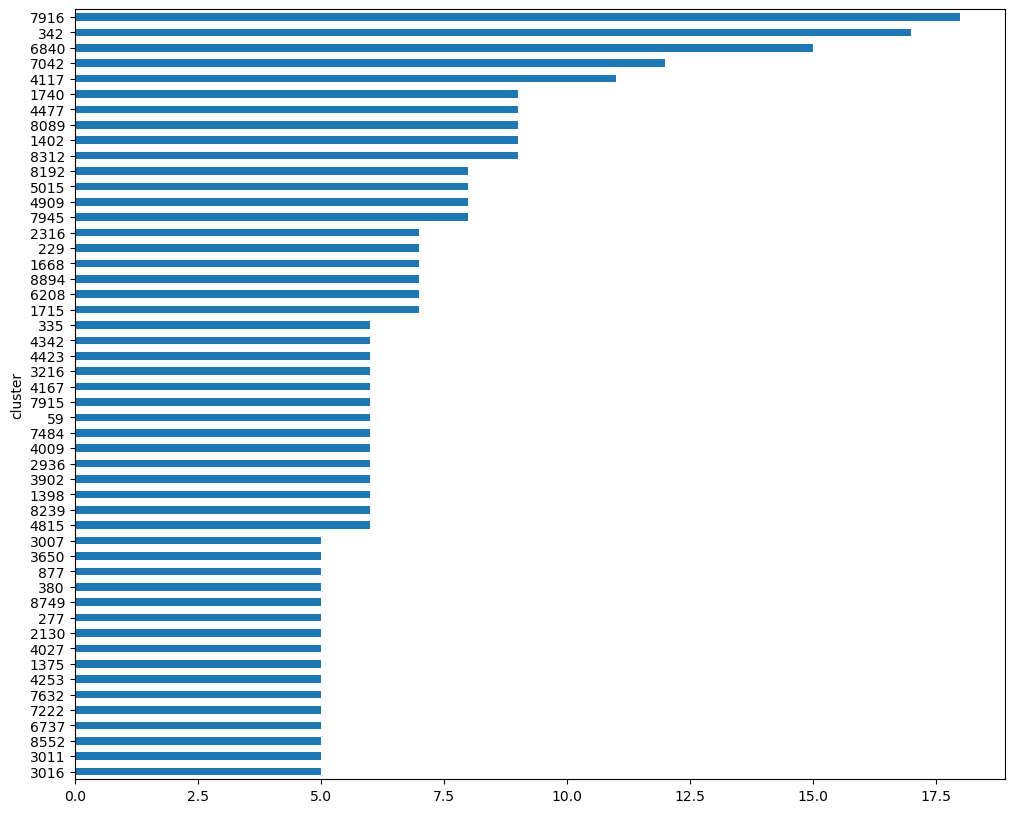

In [45]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [46]:
top_clusters = df['cluster'].value_counts()[0:20].index.values
top_clusters

array([7916,  342, 6840, 7042, 4117, 1740, 4477, 8089, 1402, 8312, 8192,
       5015, 4909, 7945, 2316,  229, 1668, 8894, 6208, 1715], dtype=int64)

In [47]:
cluster = top_clusters[0]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Police responding to an active shooter situation at a Detroit area synagogue.',
       'Police respond to active shooter situation at a Michigan synagogue',
       'Police responding to an active shooter situation at a synagogue in Michigan.',
       'Police are responding to an active shooter report at a Detroit area synagogue.',
       'Active shooter situation at Detroit, Michigan synagogue',
       'Police are responding to an active shooter situation at Temple Israel.',
       'Report on an active shooter situation at a synagogue in Michigan',
       'Active shooter situation at Michigan synagogue',
       'Police responding to active shooter situation at a Michigan synagogue',
       'Police responding to active shooter situation at suburban Detroit synagogue',
       'Police responding to an active shooter situation at Temple Israel.',
       'Police are responding to an active shooter report at a synagogue in Michigan.',
       'Police are responding to an active shoote

In [48]:
cluster = top_clusters[1]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Another event at the Denver Library',
       'An event at the Denver Library', 'Event at Denver Library',
       'Event at Denver Library', 'Event at Denver Library',
       'Event at Denver Library',
       'Information about a specific event at the Denver Library',
       'Information about another specific event at the Denver Library',
       'Event scheduled at Denver Library',
       'Event scheduled at Denver Library',
       'Event scheduled at Denver Library',
       'Another event at Denver Library', 'Event at Denver Library',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.',
       'An event is scheduled at the Denver Library.'], dtype=object)

In [49]:
cluster = top_clusters[2]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Police respond to an active shooter incident at a synagogue in Michigan.',
       'A shooting incident occurred at Temple Israel in West Bloomfield, Michigan.',
       'Report of an active shooter at Temple Israel in Michigan',
       'Attack at Temple Israel in West Bloomfield, Michigan.',
       'Police respond to report of active shooter at Detroit area synagogue',
       'Active shooter at Temple Israel in Michigan',
       'Active shooter reported at Temple Israel in West Bloomfield',
       'Shooting at Temple Israel in West Bloomfield',
       'Police respond to report of active shooter',
       'Police respond to a report of an active shooter at a synagogue in Michigan',
       'Police respond to reports of an active shooter at a synagogue in Michigan.',
       'Active shooter reported at Temple Israel in Michigan',
       'Report of an active shooter at a synagogue in Michigan',
       'Police respond to report of an active shooter at a Detroit area synagogue.',
      

In [50]:
cluster = top_clusters[3]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.',
       'Claims or discussions related to current news or topics of interest.'],
      dtype=object)

In [52]:
cluster = top_clusters[4]

df[df['cluster']==cluster].head(20)['claim'].values

array(['An article discusses the conditions in immigration detention facilities.',
       'The article discusses the conditions of immigration detention.',
       'Report on the conditions of immigration detention facilities.',
       'The article discusses the conditions of immigration detention facilities.',
       'The article discusses the conditions of immigration detention.',
       'The article discusses the conditions of immigration detention facilities.',
       'Discussing the conditions of immigration detention',
       'The article discusses conditions in immigration detention facilities.',
       'claims about the conditions in immigration detention facilities',
       'The article discusses the conditions of immigration detention facilities.',
       'Discusses the conditions of immigration detention facilities.'],
      dtype=object)

In [53]:
cluster = top_clusters[5]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claim related to a news article',
       'Claim related to a news article',
       'Claim related to a news article',
       'Claim related to a news article',
       'Claim related to news article cm246kdxjr7o',
       'Claim related to news article cvg1ye879r1o',
       'Claim related to news article c309478l04go',
       'Claim related to news article clygqnlpwero',
       'Claim related to news article c1w558gvrdro'], dtype=object)

In [54]:
cluster = top_clusters[6]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL',
       'Claim related to a news article or topic covered by the URL'],
      dtype=object)

In [55]:
cluster = top_clusters[7]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Police are responding to reports of an active shooter at a synagogue in Detroit area.',
       'Police are responding to reports of a shooting at a synagogue in the Detroit area.',
       'Police are responding to reports of a shooting at a synagogue in Michigan.',
       'Reports of a shooting at a synagogue in Michigan',
       'Police are responding to reports of an active shooter situation.',
       'Officials are responding to reports of an active shooter.',
       'Police are responding to reports of an active shooter at a metro Detroit synagogue.',
       'Michigan police are responding to reports of an active shooter at a synagogue.',
       'Police are responding to reports of an active shooter at a temple in West Bloomfield.'],
      dtype=object)

In [56]:
cluster = top_clusters[8]

df[df['cluster']==cluster].head(20)['claim'].values

array(['A news article related to a specific topic or event.',
       'News article related to a specific topic or event',
       'News article related to a specific topic or event',
       'News article related to a specific topic or event',
       'A news article related to a specific topic or event.',
       'A news article related to a specific topic or event.',
       'A news update related to a specific topic or event.',
       'A news update related to a specific topic or event.',
       'A news update related to a specific topic or event.'],
      dtype=object)

In [57]:
cluster = top_clusters[9]

df[df['cluster']==cluster].head(20)['claim'].values

array(['No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible', 'No specific claim discernible',
       'No specific claim discernible'], dtype=object)

In [58]:
cluster = top_clusters[10]

df[df['cluster']==cluster].head(20)['claim'].values

array(['Active shooter situation reported in Michigan',
       'Active shooter situation reported at Old Dominion University',
       'Active shooter situation reported at a synagogue in Detroit.',
       'Active shooter situation reported at Old Dominion University',
       'Active shooter situation reported',
       'Active shooter reported at a synagogue in Michigan.',
       'Active shooter situation reported at a synagogue in Michigan.',
       'Active shooter reported at a synagogue in Michigan.'],
      dtype=object)

# Find a Cluster

Sometimes you will know what you are looking for but not know what cluster it exists in. This will help you find it.

In [68]:
search_term = 'arrest'

df[df['claim'].str.contains(search_term)]

,claim,url,domain,url_domain,date_added,cluster
31,Report on arrests in the Mid-Hudson Valley,https://www.dailyfreeman.com/2026/03/14/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-14 12:56:57-07:00,29
51,A man has been arrested in connection with a d...,https://ksat.com/news/local/2026/03/14/man-arr...,ksat.com,ksat.com,2026-03-14 12:53:31-07:00,49
82,Incident involving an Islamist arrested for ar...,https://rumble.com/v773ila-islamist-arrested-f...,thelibertydaily.com,rumble.com,2026-03-14 12:47:54-07:00,73
99,Denton police arrest two individuals in connec...,https://kten.com/news/state/denton-police-arre...,kten.com,kten.com,2026-03-14 12:44:54-07:00,88
124,A teacher in Queens was arrested for sexual ab...,https://nypost.com/2026/03/14/us-news/queens-t...,nypost.com,nypost.com,2026-03-14 12:41:08-07:00,113
...,...,...,...,...,...,...
9877,Claim about two men suspected of impersonating...,https://www.pressenterprise.com/2026/03/12/2-m...,pressenterprise.com,pressenterprise.com,2026-03-12 10:53:09-07:00,9005
9904,Woman arrested in connection to the Elephants ...,https://youroregonnews.com/2026/03/12/woman-ar...,oregoncapitalinsider.com,youroregonnews.com,2026-03-12 10:49:56-07:00,9027
9913,"Police in Eugene arrested individuals, seizing...",https://kezi.com/news/local/eugene-drug-arrest...,kezi.com,kezi.com,2026-03-12 10:48:24-07:00,9031
9984,The Gulf Shores police confirmed the arrest of...,https://mynbc15.com/news/local/gulf-shores-pd-...,mynbc15.com,mynbc15.com,2026-03-12 09:45:05-07:00,9087


In [69]:
top_clusters = df[df['claim'].str.contains(search_term)]['cluster'].value_counts()[0:10].index.values

In [70]:
cluster = top_clusters[0]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
2464,Parents of two girls who died in a mobile home...,https://www.sgvtribune.com/2026/03/13/parents-...,sgvtribune.com,sgvtribune.com,2026-03-13 19:17:52-07:00,2316
2488,Parents of two girls who died in a fire are ar...,https://www.dailynews.com/2026/03/13/parents-o...,dailynews.com,dailynews.com,2026-03-13 19:12:42-07:00,2316
2493,Parents of two girls who died in a mobile home...,https://www.dailybreeze.com/2026/03/13/parents...,dailybreeze.com,dailybreeze.com,2026-03-13 19:09:30-07:00,2316
2500,Parents of two girls who died in a fire have b...,https://www.ocregister.com/2026/03/13/parents-...,ocregister.com,ocregister.com,2026-03-13 19:07:29-07:00,2316
2505,Parents of two girls who died in a mobile home...,https://www.presstelegram.com/2026/03/13/paren...,presstelegram.com,presstelegram.com,2026-03-13 19:05:33-07:00,2316
2519,Parents of two girls who died in fire are arre...,https://www.pressenterprise.com/2026/03/13/par...,pressenterprise.com,pressenterprise.com,2026-03-13 19:00:57-07:00,2316
2520,Parents of two girls who died in a mobile home...,https://www.pasadenastarnews.com/2026/03/13/pa...,pasadenastarnews.com,pasadenastarnews.com,2026-03-13 18:59:43-07:00,2316


In [71]:
cluster = top_clusters[1]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
31,Report on arrests in the Mid-Hudson Valley,https://www.dailyfreeman.com/2026/03/14/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-14 12:56:57-07:00,29
4403,Report on arrests in the Mid Hudson Valley for...,https://www.dailyfreeman.com/2026/03/13/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-13 11:29:11-07:00,29
9012,Report on arrests in the Mid Hudson Valley for...,https://www.dailyfreeman.com/2026/03/12/mid-hu...,dailyfreeman.com,dailyfreeman.com,2026-03-12 13:15:02-07:00,29


In [72]:
cluster = top_clusters[2]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
6031,A pedophile catcher is making many arrests in ...,https://www.themorningsun.com/2026/03/13/a-ped...,themorningsun.com,themorningsun.com,2026-03-13 04:04:16-07:00,5569
6053,A pedophile catcher is making numerous arrests...,https://www.macombdaily.com/2026/03/13/a-pedop...,macombdaily.com,macombdaily.com,2026-03-13 03:52:46-07:00,5569
6086,A pedophile catcher is making numerous arrests...,https://www.theoaklandpress.com/2026/03/13/a-p...,theoaklandpress.com,theoaklandpress.com,2026-03-13 03:47:31-07:00,5569


In [73]:
cluster = top_clusters[3]

df[df['cluster']==cluster].head(20)

,claim,url,domain,url_domain,date_added,cluster
9628,An 11-year-old has been arrested and is facing...,https://yahoo.com/news/news/articles/11-old-ar...,yahoo.com/news,yahoo.com/news,2026-03-12 11:25:07-07:00,8803
9693,An 11-year-old has been arrested and faces mur...,https://abcnews.com/US/11-year-arrested-faces-...,abcnews.go.com,abcnews.com,2026-03-12 11:16:29-07:00,8803
9705,An 11-year-old has been arrested and faces cha...,https://www.aol.com/articles/11-old-arrested-f...,aol.com,aol.com,2026-03-12 11:14:47-07:00,8803


# Graph Analysis

Every answer is a graph edgelist. Every row is a graph link.

In [74]:
df.head(1)

,claim,url,domain,url_domain,date_added,cluster
0,Event for a school break program on April 24,https://dtpd.org/calendar/events/school-s-out-...,dtpd.org,dtpd.org,2026-03-14 13:05:28-07:00,0


Edge: domain -> url_domain

Claim: what was claimed to have happened

url_domain: the source website

domain: the amplifiying website (usually the same as source, but very interesting when not! maps the internet)

date_added: when we saw the claim on the internet, UTC time.

In [75]:
import networkx as nx

In [76]:
G = nx.from_pandas_edgelist(df, source='domain', target='url_domain')
print(G)

Graph with 1348 nodes and 1457 edges


I have made this extremely easy for Data Scientists. Use the API, get data back. Load it into a DataFrame. Use it.

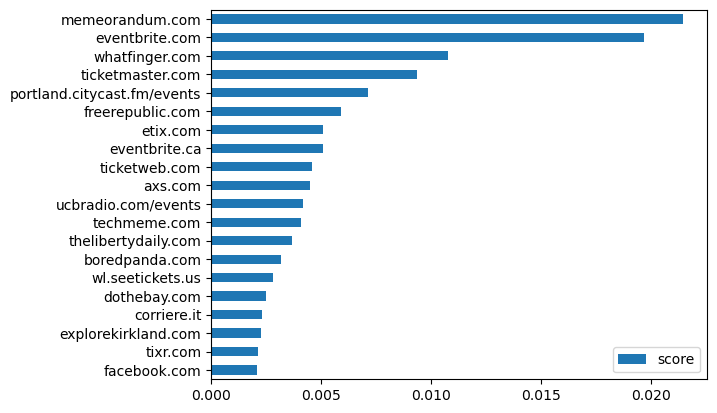

In [77]:
scores = nx.pagerank(G)
score_df = pd.DataFrame([scores]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df[0:20].plot.barh().invert_yaxis()

In [78]:
# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=3, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency)
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

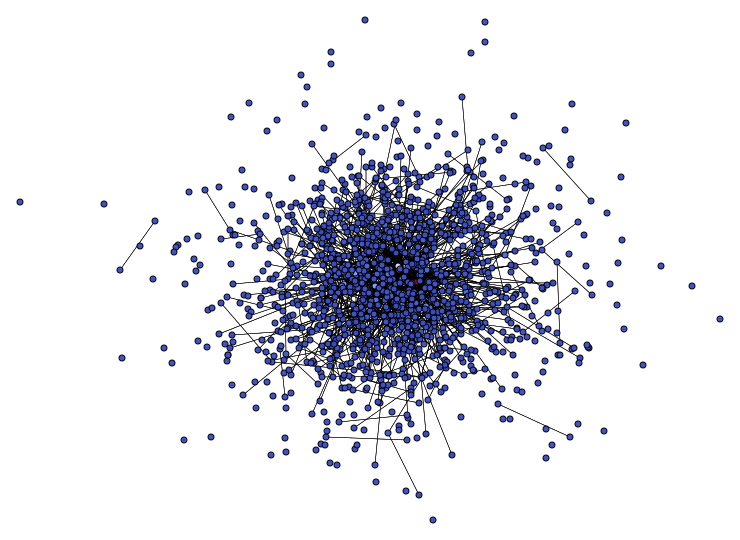

In [79]:
draw_graph(G)

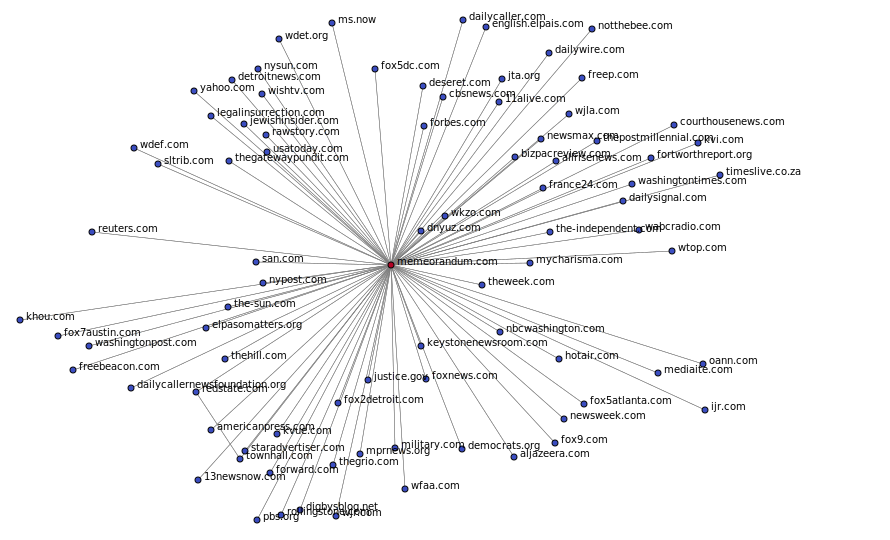

In [80]:
ego = 'memeorandum.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)

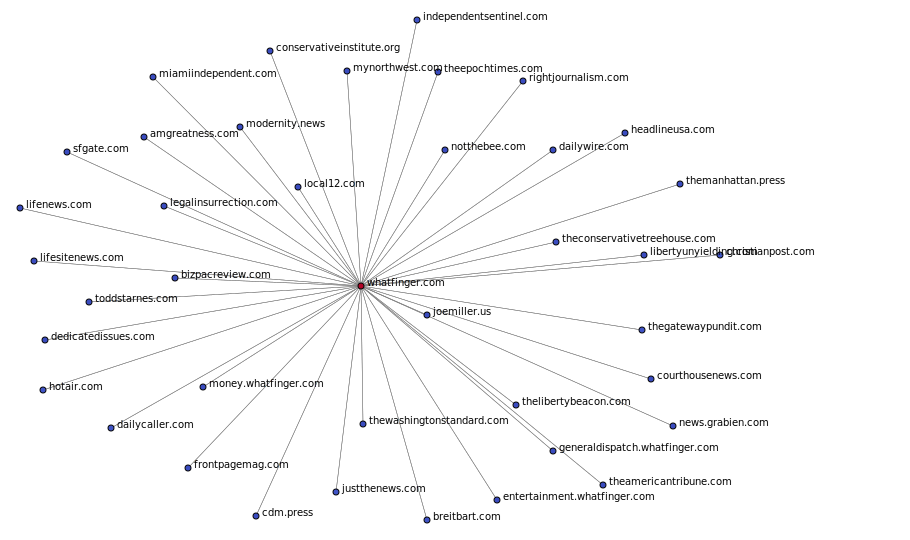

In [81]:
ego = 'whatfinger.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)

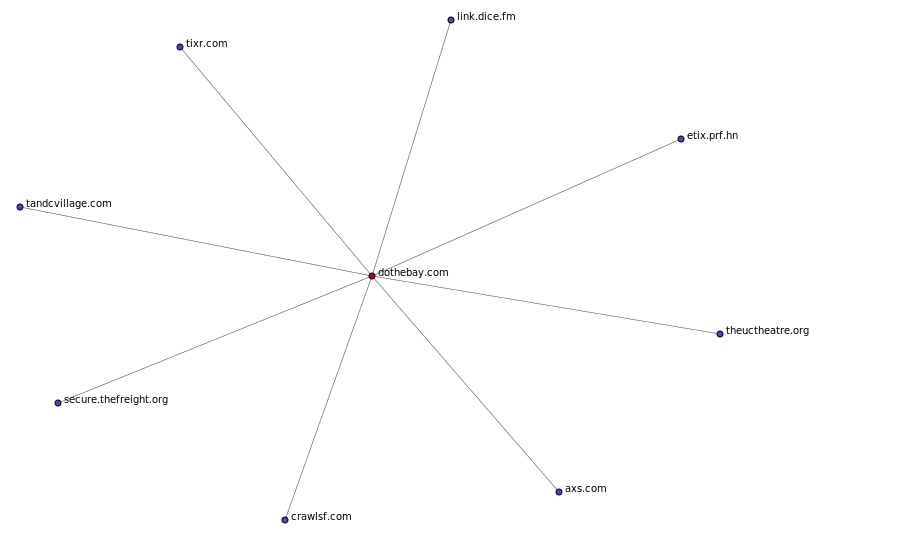

In [82]:
ego = 'dothebay.com'

G_check = nx.ego_graph(G, ego)

draw_graph(G_check, show_names=True)